<a href="https://colab.research.google.com/github/Tmiller68/machine-learning-fundamentals/blob/main/Day_5_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [2]:
import pandas as pd
df=pd.read_csv("creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [6]:
fraud_percentage=df["Class"].mean()*100
print(f"Fraud Percentage: {fraud_percentage: 3f}%")

Fraud Percentage:  0.172749%


In [7]:
from sklearn.model_selection import train_test_split
X=df.drop(columns="Class")
Y=df["Class"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

In [8]:
print(X_train.shape)
print(X_test.shape)

(227845, 30)
(56962, 30)


In [9]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, Y_train)
dummy_preds = dummy.predict(X_test)
dummy_accuracy=accuracy_score(Y_test, dummy_preds)
dummy_accuracy

0.9982795547909132

In [10]:
dummy_cm=confusion_matrix(Y_test, dummy_preds)
dummy_cm

array([[56864,     0],
       [   98,     0]])

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
log_reg=Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])
log_reg.fit(X_train, Y_train)
log_preds=log_reg.predict(X_test)


In [12]:
log_accuracy = accuracy_score(Y_test, log_preds)
log_cm = confusion_matrix(Y_test, log_preds)

print("Logistic Regression Accuracy:", log_accuracy)
print("Confusion Matrix:")
print(log_cm)

Logistic Regression Accuracy: 0.9991397773954567
Confusion Matrix:
[[56851    13]
 [   36    62]]


In [13]:
print("Dummy Classifier Accuracy:")
print(dummy_accuracy)

print("Dummy Classifier Confusion Matrix:")
print(dummy_cm)

print("\nLogistic Regression Accuracy:")
print(log_accuracy)

print("Logistic Regression Confusion Matrix:")
print(log_cm)

Dummy Classifier Accuracy:
0.9982795547909132
Dummy Classifier Confusion Matrix:
[[56864     0]
 [   98     0]]

Logistic Regression Accuracy:
0.9991397773954567
Logistic Regression Confusion Matrix:
[[56851    13]
 [   36    62]]


The DummyClassifier achieved about 99.83% accuracy because the dataset is extremely imbalanced, with the vast majority of transactions being non-fraudulent. Since it always predicts the majority class, it correctly classifies almost every normal transaction. However, the confusion matrix shows that it failed to detect all 98 fraud cases, resulting in zero true positives. This demonstrates why accuracy alone can be misleading when evaluating models on imbalanced datasets.

What confused me today was how to use the DummyClassifier. At first, I wasn’t sure how to set it up or what strategy="most_frequent" was telling the classifier to do. After using .fit() and .predict(), I understood that it follows the same basic process as a normal model, but instead of learning patterns from the features, it simply predicts the most common class.

In [14]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, log_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [15]:
report=classification_report(
    Y_test,
    log_preds,
    output_dict=True
)
fraud_precision = report["1"]["precision"]
fraud_recall = report["1"]["recall"]
fraud_f1 = report["1"]["f1-score"]

print("Fraud Precision:", fraud_precision)
print("Fraud Recall:", fraud_recall)
print("Fraud F1-score:", fraud_f1)

Fraud Precision: 0.8266666666666667
Fraud Recall: 0.6326530612244898
Fraud F1-score: 0.7167630057803468


I would choose 60% precision and 90% recall for a real fraud detection system. A higher recall means the model catches more of the actual fraudulent transactions, which is important because missed fraud could cause financial loss. The lower precision would mean more normal transactions are falsely flagged, but those cases could still be reviewed. In this situation, I would rather investigate extra transactions than allow more fraud to go undetected.

In [16]:
log_probs = log_reg.predict_proba(X_test)[:, 1]

log_probs[:10]

array([6.66589547e-05, 3.65855419e-05, 6.07869420e-06, 1.04140855e-04,
       7.65924761e-03, 2.28829338e-04, 5.12814321e-05, 1.41758870e-04,
       7.59584282e-04, 3.49946251e-05])

ROC-AUC: 0.9605494455801453


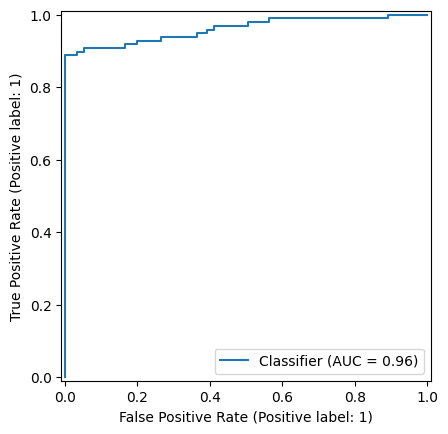

In [17]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

RocCurveDisplay.from_predictions(Y_test, log_probs)

roc_auc = roc_auc_score(Y_test, log_probs)
print("ROC-AUC:", roc_auc)

PR-AUC: 0.7413820992780461


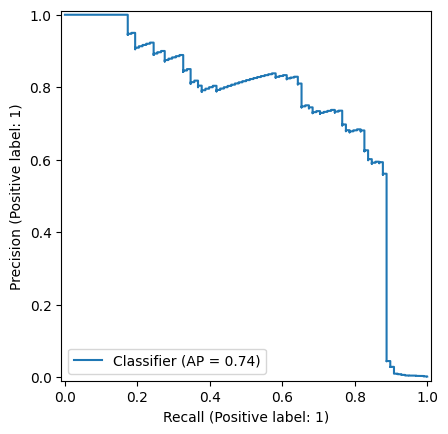

In [18]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

PrecisionRecallDisplay.from_predictions(Y_test, log_probs)

pr_auc = average_precision_score(Y_test, log_probs)
print("PR-AUC:", pr_auc)

In [19]:
average_precision_score(Y_test, log_probs)

np.float64(0.7413820992780461)

In [20]:
from sklearn.metrics import precision_score, recall_score
import pandas as pd

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

results = []

for threshold in thresholds:
    threshold_preds = (log_probs >= threshold).astype(int)

    precision = precision_score(Y_test, threshold_preds)
    recall = recall_score(Y_test, threshold_preds)

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall
    })

threshold_table = pd.DataFrame(results)

threshold_table

,Threshold,Precision,Recall
0,0.1,0.700935,0.765306
1,0.2,0.734694,0.734694
2,0.3,0.731183,0.693878
3,0.4,0.752941,0.653061
4,0.5,0.826667,0.632653
5,0.6,0.826667,0.632653
6,0.7,0.830986,0.602041
7,0.8,0.828125,0.540816
8,0.9,0.816667,0.500000


In [21]:
threshold_preds = (log_probs >= threshold).astype(int)

I would choose a threshold of 0.2 because it provides a good balance between precision and recall, with both being about 73.5%. Lowering the threshold from the default 0.5 allows the model to detect more fraudulent transactions without sacrificing too much precision. For a fraud detection system, I would prioritize catching more fraud even if it results in some additional false positives.

What confused me today was the syntax in predict_proba(X_test)[:, 1]. At first, I did not understand what [:, 1] was selecting from the output. I learned that predict_proba() returns probabilities for both classes, and [:, 1] selects the probability for class 1, which is fraud, for every row.

In [22]:
!pip install -q imbalanced-learn

In [23]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [24]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [25]:
plain_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

plain_scores = cross_val_score(
    plain_pipeline,
    X_train,
    Y_train,
    cv=cv,
    scoring="average_precision"
)

print("Plain Logistic Regression PR-AUC:")
print(plain_scores.mean())

Plain Logistic Regression PR-AUC:
0.7614969310778783


In [26]:
balanced_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

balanced_scores = cross_val_score(
    balanced_pipeline,
    X_train,
    Y_train,
    cv=cv,
    scoring="average_precision"
)

print("Balanced Logistic Regression PR-AUC:")
print(balanced_scores.mean())

Balanced Logistic Regression PR-AUC:
0.7571360842475147


In [27]:
smote_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

smote_scores = cross_val_score(
    smote_pipeline,
    X_train,
    Y_train,
    cv=cv,
    scoring="average_precision"
)

print("SMOTE Logistic Regression PR-AUC:")
print(smote_scores.mean())

SMOTE Logistic Regression PR-AUC:
0.7527513433898763


In [28]:
day4_results = pd.DataFrame({
    "Model": [
        "Plain Logistic Regression",
        "Balanced Logistic Regression",
        "SMOTE Logistic Regression"
    ],
    "Mean PR-AUC": [
        plain_scores.mean(),
        balanced_scores.mean(),
        smote_scores.mean()
    ]
})

day4_results

,Model,Mean PR-AUC
0,Plain Logistic Regression,0.761497
1,Balanced Logistic Regression,0.757136
2,SMOTE Logistic Regression,0.752751


The plain logistic regression performed the best with a mean PR-AUC of about 0.7615. The balanced model was slightly lower at 0.7571, while the SMOTE model had the lowest score at 0.7528. I would choose the plain logistic regression because it achieved the highest PR-AUC without requiring additional class weighting or synthetic samples. These results also show that techniques designed to handle class imbalance do not automatically improve model performance.

What confused me today was why I needed to use ImbPipeline instead of the regular Pipeline when using SMOTE. I learned that the imbalanced-learn pipeline allows SMOTE() to be included as a step during training, so it can resample the training data correctly within each cross-validation fold.

In [29]:
from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    PrecisionRecallDisplay
)

import matplotlib.pyplot as plt

In [31]:
negative_count = (Y_train == 0).sum()
positive_count = (Y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative:", negative_count)
print("Positive:", positive_count)
print("Scale Pos Weight:", scale_pos_weight)

Negative: 227451
Positive: 394
Scale Pos Weight: 577.2868020304569


In [32]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

In [33]:
param_distributions = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [35]:
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, Y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [100, 200, 300, 400],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='average_precision', verbose=1)

In [37]:
scoring="average_precision"

In [36]:
print("Best Parameters:")
print(random_search.best_params_)

print("Best CV PR-AUC:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 0.7, 'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best CV PR-AUC:
0.8538751890032147


In [38]:
best_xgb = random_search.best_estimator_

In [39]:
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

In [40]:
chosen_threshold = 0.2

xgb_preds = (xgb_probs >= chosen_threshold).astype(int)

In [41]:
final_cm = confusion_matrix(Y_test, xgb_preds)

final_precision = precision_score(Y_test, xgb_preds)
final_recall = recall_score(Y_test, xgb_preds)
final_f1 = f1_score(Y_test, xgb_preds)

final_roc_auc = roc_auc_score(Y_test, xgb_probs)
final_pr_auc = average_precision_score(Y_test, xgb_probs)

print("Chosen Threshold:", chosen_threshold)

print("\nConfusion Matrix:")
print(final_cm)

print("\nFraud Precision:", final_precision)
print("Fraud Recall:", final_recall)
print("Fraud F1:", final_f1)

print("\nROC-AUC:", final_roc_auc)
print("PR-AUC:", final_pr_auc)

Chosen Threshold: 0.2

Confusion Matrix:
[[56851    13]
 [   15    83]]

Fraud Precision: 0.8645833333333334
Fraud Recall: 0.8469387755102041
Fraud F1: 0.8556701030927835

ROC-AUC: 0.9791143279202508
PR-AUC: 0.8833069861925221


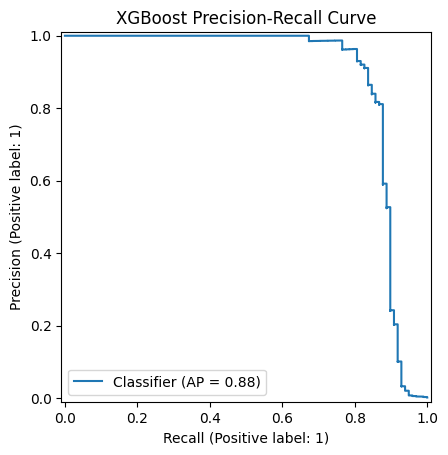

In [42]:
PrecisionRecallDisplay.from_predictions(
    Y_test,
    xgb_probs
)

plt.title("XGBoost Precision-Recall Curve")
plt.show()

The final XGBoost model performed well on the imbalanced credit card fraud dataset. Using a threshold of 0.2, the model achieved a fraud precision of 86.46%, recall of 84.69%, and an F1-score of 85.57%. The model also achieved a ROC-AUC of 97.91% and a PR-AUC of 83.06%. The confusion matrix showed that the model correctly detected 83 of the 98 fraudulent transactions while missing 15 and incorrectly flagging only 13 normal transactions.

I chose a threshold of 0.2 because fraud detection places a high importance on recall, since failing to identify a fraudulent transaction can be costly. The lower threshold allows the model to identify more potential fraud while still maintaining strong precision. Compared with the logistic regression model from earlier in the week, XGBoost was able to catch more fraudulent transactions while maintaining good precision. In the future, I would experiment with additional XGBoost hyperparameters and threshold-selection methods to see if recall could be improved further without creating too many false positives.

On Day 1, the DummyClassifier achieved 99.83% accuracy while detecting zero fraudulent transactions, but by Day 5 I was able to build an XGBoost model that detected 83 of the 98 fraud cases, showing why evaluating an imbalanced model requires more than accuracy.

What confused me today was the syntax for RandomizedSearchCV because there were several parameters being passed into the function at once. I especially was not sure what param_distributions was doing or how it connected to the XGBoost model. I learned that param_distributions gives RandomizedSearchCV the different parameter values it can randomly test to find a better version of the model.